# Seção 1 – Modelagem preditiva da venda diária
**Pergunta:** quanto o e-commerce vai vender (projeção de receita aprovada e de nº de pedidos) em cada dia, com **7 dias de antecedência**?

Desenho da solução, resumido:
1. Série diária (242 dias) – amostra pequena, então modelos simples e regularizados são o ponto de partida.
2. Baseline ingênuo sazonal (mesmo dia da semana, 7 dias atrás) como régua mínima.
3. Ridge (interpretável) e LightGBM (captura não linearidades e interações) sobre o log do alvo, mais a média dos dois.
4. Validação temporal: *walk-forward* (4 janelas de 14 dias, treino sempre no passado) e *holdout* nos últimos 30 dias (junho/2026), tocado uma única vez.
5. Dois cenários de informação: **sem plano promocional** (só calendário + histórico) e **com plano promocional**
   (acrescenta a taxa de desconto do dia como se fosse conhecida com antecedência; é um limite superior otimista, testado na seção de sensibilidade).

In [1]:
import json, sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from sklearn.inspection import permutation_importance
from src.data import carregar, serie_diaria
from src.features import calendario, com_defasagens, H
from src.modeling import metricas, modelos, prever_modelo, baseline_sazonal, DIAS_HOLDOUT
from src import tuning as T
from src.benchmarks import modelo_xgboost
from src.viz import aplicar_estilo, salvar, milhoes, AZUL, LARANJA, AQUA, CINZA
aplicar_estilo()
d = serie_diaria(carregar())
d['tx_desc'] = d.vlr_venda_desconto / (d.receita_aprovada + d.vlr_venda_desconto)
ALVOS = {'receita_aprovada': 'Receita aprovada', 'nr_pedidos': 'Nº de pedidos'}
R = {}
N_FOLDS, PASSO = 4, 14
print(f'Horizonte H = {H} dias | holdout = {DIAS_HOLDOUT} dias | walk-forward = {N_FOLDS} x {PASSO} dias')

Horizonte H = 7 dias | holdout = 30 dias | walk-forward = 4 x 14 dias


## Seleção de indicadores: o que projetar e o que usar como insumo
A base traz quatro medidas por hora, categoria e canal. A escolha do que projetar e do que usar como variável explicativa é uma decisão de negócio:

| Indicador | Papel | Justificativa |
|---|---|---|
| `receita_aprovada` | **Alvo** | É o número que vira meta e leitura financeira. Líquida de desconto; sofre com as linhas ≤ 0 |
| `nr_pedidos` | **Alvo** | Volume operacional (logística, atendimento, mídia). Não depende do valor do desconto, por isso é mais estável |
| `qt_material` (itens) | Não modelado | Move junto com pedidos (ver correlação abaixo) e traria pouca informação nova; itens por pedido é estável |
| `vlr_venda_desconto` / taxa de desconto | **Insumo**, não alvo | É decisão do comercial (driver); usado só como variável e com cuidado: contemporâneo é circular |
| ticket médio e preço por item | Derivados | `receita ÷ pedidos` e `receita ÷ itens`: já determinados pelos dois alvos |

Nível de projeção: **total diário** (todos os canais e categorias). É o que o planejamento usa e é bem menos ruidoso que o nível hora × categoria × canal; a abertura por segmento fica como próximo passo.

In [2]:
kpi = d[['receita_aprovada', 'nr_pedidos', 'qt_material', 'vlr_venda_desconto']].copy()
kpi['ticket'] = kpi.receita_aprovada / kpi.nr_pedidos
kpi['itens_por_pedido'] = kpi.qt_material / kpi.nr_pedidos
kpi['tx_desc'] = d.tx_desc
R['corr_kpis'] = kpi.corr().round(2).to_dict()
kpi.corr().round(2)

,receita_aprovada,nr_pedidos,qt_material,vlr_venda_desconto,ticket,itens_por_pedido,tx_desc
receita_aprovada,1.00,0.97,0.96,0.95,-0.45,0.30,0.55
nr_pedidos,0.97,1.00,1.00,0.98,-0.58,0.37,0.60
qt_material,0.96,1.00,1.00,0.98,-0.59,0.44,0.62
vlr_venda_desconto,0.95,0.98,0.98,1.00,-0.55,0.46,0.70
ticket,-0.45,-0.58,-0.59,-0.55,1.00,-0.50,-0.65
itens_por_pedido,0.30,0.37,0.44,0.46,-0.50,1.00,0.66
tx_desc,0.55,0.60,0.62,0.70,-0.65,0.66,1.00


## Features
- **Calendário** (conhecido no futuro): dia da semana (variáveis binárias), fim de semana, dia do mês, janela pós-pagamento (dias 5–7),
  fim de mês, feriados, Black Friday (dia e janela) e **Beauty Week (novembro inteiro)**, Cyber Monday, pré-Natal, Natal/Ano Novo, Carnaval, pré-Dia das Mães, pré-Dia dos Namorados e tendência `t` (contador de dias; fora de novembro a inclinação da série é ≈ 0, então seu papel é pequeno: ver o teste de remoção mais abaixo).
- **Histórico** (deslocado em ≥ 7 dias para não vazar informação): lag 7, lag 14, médias móveis de 7 e 14 dias e média do mesmo dia da semana nas 3 últimas semanas.
- **Informação promocional** (cenário B): taxa de desconto do dia (circular; ver teste de sensibilidade).

Alvo em `log1p` para estabilizar a variância (o nível cai de ~4 mi/dia em novembro para ~1,5 mi/dia depois).

**Sazonalidade de novembro (Beauty Week / Black Friday).** A campanha dura o mês inteiro, com pico no dia da Black Friday: novembro responde por ~26% da receita do período
(~34% dos pedidos), e a janela da Black Friday sozinha por ~9%. Por isso há duas variáveis: `beauty_week` (novembro inteiro, o nível da campanha) e `bf_dia`/`bf_janela` (o pico).
Para não descartar novembro do treino, as médias móveis do início da série usam o histórico disponível (mínimo de 3 dias), de modo que o treino começa em 10/11 e não em 22/11.
**Limite:** há um único novembro. O modelo aprende o nível da campanha, mas **não dá para validá-lo fora da amostra**; isso exigiria o ano anterior.

In [3]:
def conjuntos(y):
    cal, lag = calendario(y.index), com_defasagens(y)
    return {'A. Sem plano promocional': cal.join(lag),
            'B. Com plano promocional (teto)': cal.join(lag).assign(tx_desc=d.tx_desc)}

def avaliar(y, X):
    X = X.dropna(); yy = y.loc[X.index]; n = len(yy) - DIAS_HOLDOUT
    preds_ho, wf = {}, {}
    # walk-forward
    for nome in ['Naive sazonal', 'Ridge', 'LightGBM', 'Média Ridge+LGBM']:
        wf[nome] = []
    for i in range(N_FOLDS):
        ini = n - PASSO * (N_FOLDS - i); te = slice(ini, ini + PASSO)
        p = {'Naive sazonal': baseline_sazonal(y, yy.index[te])}
        for nm, mk in modelos().items():
            p[nm], _ = prever_modelo(mk, X.iloc[:ini], yy.iloc[:ini], X.iloc[te])
        p['Média Ridge+LGBM'] = (p['Ridge'] + p['LightGBM']) / 2
        for k, v in p.items(): wf[k].append(metricas(yy.iloc[te], v)['WAPE %'])
    # holdout
    te = slice(n, None)
    preds_ho['Naive sazonal'] = baseline_sazonal(y, yy.index[te])
    fitted = {}
    for nm, mk in modelos().items():
        preds_ho[nm], fitted[nm] = prever_modelo(mk, X.iloc[:n], yy.iloc[:n], X.iloc[te])
    preds_ho['Média Ridge+LGBM'] = (preds_ho['Ridge'] + preds_ho['LightGBM']) / 2
    linhas = []
    for k, p in preds_ho.items():
        m = metricas(yy.iloc[te], p)
        linhas.append({'modelo': k, 'WAPE walk-forward (%)': np.mean(wf[k]), 'WAPE holdout (%)': m['WAPE %'],
                       'MAPE holdout (%)': m['MAPE %'], 'MAE holdout': m['MAE'], 'Viés holdout (%)': m['Viés %']})
    return pd.DataFrame(linhas).set_index('modelo'), preds_ho, fitted, X, yy, n

tabelas, saidas = {}, {}
for alvo, rotulo in ALVOS.items():
    y = d[alvo]
    for cen, X in conjuntos(y).items():
        t, ph, fit, Xc, yy, n = avaliar(y, X)
        tabelas[(alvo, cen)] = t; saidas[(alvo, cen)] = (ph, fit, Xc, yy, n)

## Resultados – receita aprovada

In [4]:
for cen in ['A. Sem plano promocional', 'B. Com plano promocional (teto)']:
    print(cen); display(tabelas[('receita_aprovada', cen)].round(1))

A. Sem plano promocional


,WAPE walk-forward (%),WAPE holdout (%),MAPE holdout (%),MAE holdout,Viés holdout (%)
modelo,,,,,
Naive sazonal,34.2,35.1,36.3,555337.5,-2.3
Ridge,23.6,29.6,31.8,467938.4,7.0
LightGBM,27.5,30.4,34.1,481271.2,10.2
Média Ridge+LGBM,24.1,29.9,32.8,473267.3,8.6


B. Com plano promocional (teto)


,WAPE walk-forward (%),WAPE holdout (%),MAPE holdout (%),MAE holdout,Viés holdout (%)
modelo,,,,,
Naive sazonal,34.2,35.1,36.3,555337.5,-2.3
Ridge,22.4,30.5,30.2,483107.5,3.4
LightGBM,29.2,29.2,28.7,461790.9,-1.4
Média Ridge+LGBM,25.1,29.3,28.9,463835.6,1.0


## Resultados – nº de pedidos

In [5]:
for cen in ['A. Sem plano promocional', 'B. Com plano promocional (teto)']:
    print(cen); display(tabelas[('nr_pedidos', cen)].round(1))

A. Sem plano promocional


,WAPE walk-forward (%),WAPE holdout (%),MAPE holdout (%),MAE holdout,Viés holdout (%)
modelo,,,,,
Naive sazonal,38.3,29.7,31.4,5060.2,-9.0
Ridge,27.2,27.3,32.4,4665.1,11.6
LightGBM,27.9,28.9,34.3,4924.0,11.6
Média Ridge+LGBM,27.0,27.4,32.7,4672.8,11.6


B. Com plano promocional (teto)


,WAPE walk-forward (%),WAPE holdout (%),MAPE holdout (%),MAE holdout,Viés holdout (%)
modelo,,,,,
Naive sazonal,38.3,29.7,31.4,5060.2,-9.0
Ridge,23.7,24.1,26.2,4111.3,9.0
LightGBM,26.4,26.8,27.2,4568.3,-4.8
Média Ridge+LGBM,24.5,24.0,25.4,4094.1,2.1


**Leitura.**
- **Seleção pelo walk-forward, não pelo holdout:** o holdout tem só 30 pontos e um mês atípico (Copa, Dia dos Namorados e fim de mês com 55% de desconto); escolher o modelo nele seria sobreajuste.
- Os modelos superam o baseline, mas o ganho é moderado: a variância dominante vem de **campanhas** que o calendário não enxerga. Saber a intensidade promocional (cenário B, com a taxa do próprio dia, limite superior otimista) ajuda pouco na receita (WAPE walk-forward 23,6% → 22,4%; no holdout não há ganho: 29,6% → 30,5%) e mais em pedidos (27,0% → 23,7% no walk-forward; 27,4% → 24,1% no holdout).
- Modelos lineares e árvores têm desempenho parecido em amostra tão curta; a média dos dois reduz variância e é a escolha mais segura.

In [6]:
# Modelo final por (alvo, cenário): menor WAPE no walk-forward
final = {}
for k, t in tabelas.items():
    cand = t.drop(index='Naive sazonal')
    final[k] = cand['WAPE walk-forward (%)'].idxmin()
resumo = pd.DataFrame({
    'modelo escolhido': pd.Series(final),
    'WAPE walk-forward (%)': pd.Series({k: tabelas[k].loc[v, 'WAPE walk-forward (%)'] for k, v in final.items()}),
    'WAPE holdout (%)': pd.Series({k: tabelas[k].loc[v, 'WAPE holdout (%)'] for k, v in final.items()}),
    'WAPE holdout naive (%)': pd.Series({k: tabelas[k].loc['Naive sazonal', 'WAPE holdout (%)'] for k in final}),
    'WAPE walk-forward naive (%)': pd.Series({k: tabelas[k].loc['Naive sazonal', 'WAPE walk-forward (%)'] for k in final}),
})
resumo.round(1)

modelo escolhido  \
receita_aprovada A. Sem plano promocional                    Ridge   
                 B. Com plano promocional (teto)             Ridge   
nr_pedidos       A. Sem plano promocional         Média Ridge+LGBM   
                 B. Com plano promocional (teto)             Ridge   

                                                  WAPE walk-forward (%)  \
receita_aprovada A. Sem plano promocional                          23.6   
                 B. Com plano promocional (teto)                   22.4   
nr_pedidos       A. Sem plano promocional                          27.0   
                 B. Com plano promocional (teto)                   23.7   

                                                  WAPE holdout (%)  \
receita_aprovada A. Sem plano promocional                     29.6   
                 B. Com plano promocional (teto)              30.5   
nr_pedidos       A. Sem plano promocional                     27.4   
                 B. Com plano promocional (teto)              24.1   

                                                  WAPE holdout naive (%)  \
receita_aprovada A. Sem plano promocional                           35.1   
                 B. Com plano promocional (teto)                    35.1   
nr_pedidos       A. Sem plano promocional                           29.7   
                 B. Com plano promocional (teto)                    29.7   

                                                  WAPE walk-forward naive (%)  
receita_aprovada A. Sem plano promocional                                34.2  
                 B. Com plano promocional (teto)                         34.2  
nr_pedidos       A. Sem plano promocional                                38.3  
                 B. Com plano promocional (teto)                         38.3

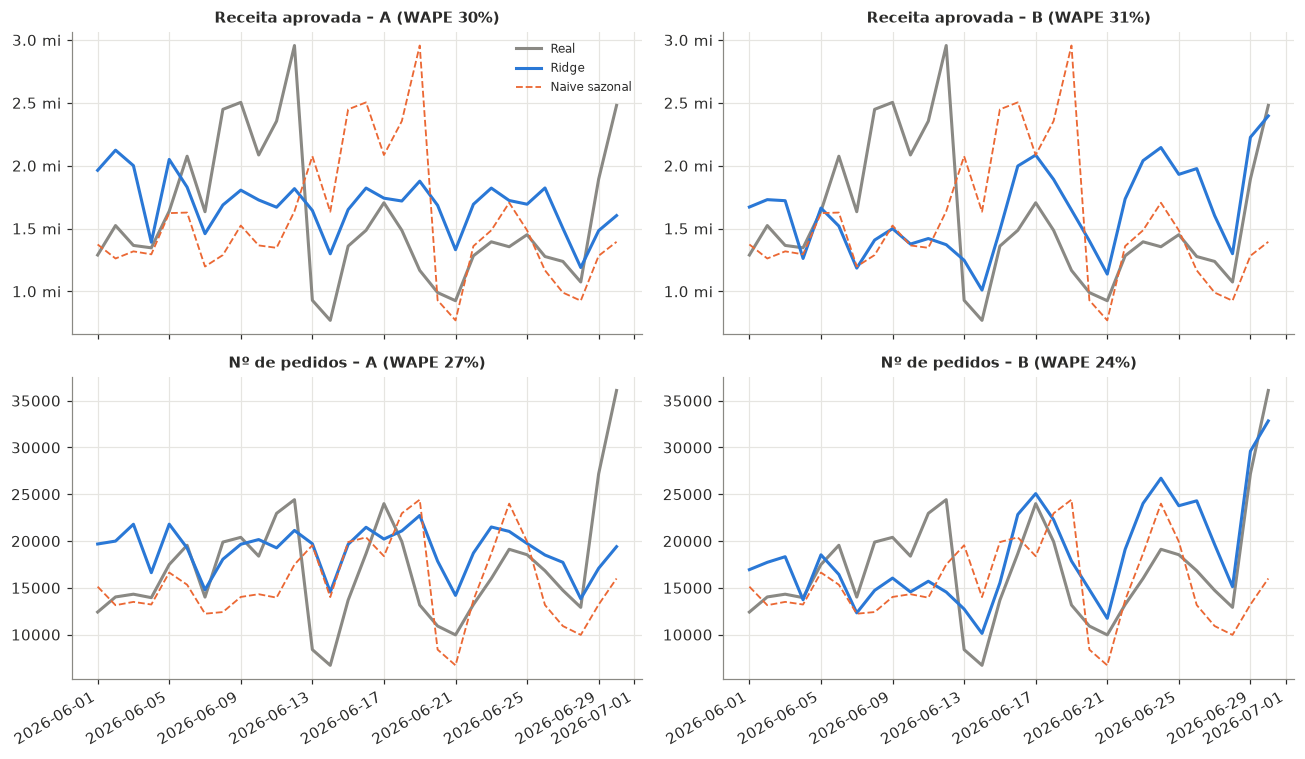

In [7]:
fig, axs = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for r, alvo in enumerate(ALVOS):
    for c, cen in enumerate(['A. Sem plano promocional', 'B. Com plano promocional (teto)']):
        ph, fit, Xc, yy, n = saidas[(alvo, cen)]
        ax = axs[r, c]; idx = yy.index[n:]
        ax.plot(idx, yy.iloc[n:], color=CINZA, label='Real')
        ax.plot(idx, ph[final[(alvo, cen)]], color=AZUL, label=final[(alvo, cen)])
        ax.plot(idx, ph['Naive sazonal'], color=LARANJA, lw=1.2, ls='--', label='Naive sazonal')
        w = tabelas[(alvo, cen)].loc[final[(alvo, cen)], 'WAPE holdout (%)']
        ax.set_title(f'{ALVOS[alvo]} – {cen[:1]} (WAPE {w:.0f}%)', fontsize=10)
        if alvo == 'receita_aprovada': ax.yaxis.set_major_formatter(FuncFormatter(milhoes))
        if r == 0 and c == 0: ax.legend(fontsize=8)
fig.autofmt_xdate(); plt.tight_layout(); salvar(fig, '08_holdout'); plt.show()

## Ajuste de hiperparâmetros e convergência
"Convergir" é o processo de treino chegar a um erro estável: em modelos de árvores com boosting, adicionar árvores reduz o erro até um ponto
em que passa a só decorar ruído. Os hiperparâmetros (nº de árvores, tamanho das árvores, taxa de aprendizado, penalidade do Ridge) definem onde isso acontece,
e são escolhidos testando várias combinações.

**Como evitei vazamento:** o ajuste usa uma **validação temporal aninhada**: grade de combinações avaliada em 3 janelas internas de 14 dias,
todas **anteriores** à primeira janela de teste do walk-forward. Depois, a combinação vencedora é avaliada nas 4 janelas externas e no holdout, que não participaram da escolha.
Cenário A (sem informação de desconto).

In [8]:
AJ = {}
LINHAS = []
for alvo, rotulo in ALVOS.items():
    ph, fit, Xc, yy, n = saidas[(alvo, 'A. Sem plano promocional')]
    padrao = {'Ridge': modelos()['Ridge'], 'LightGBM': modelos()['LightGBM'], 'XGBoost': modelo_xgboost}
    for nome in ['Ridge', 'LightGBM', 'XGBoost']:
        melhor, tab = T.buscar(nome, Xc, yy, n)
        grade, fab = T.GRADES[nome]
        for cfg, make, par in [('padrão', padrao[nome], '-'), ('ajustada', fab(**melhor), str(melhor))]:
            wf, ho, _ = T.avaliar(make, Xc, yy, n)
            LINHAS.append({'alvo': rotulo, 'modelo': nome, 'configuração': cfg, 'parâmetros': par,
                           'WAPE walk-forward (%)': wf, 'WAPE holdout (%)': ho['WAPE %']})
        AJ[(alvo, nome)] = (melhor, tab)
aj = pd.DataFrame(LINHAS).set_index(['alvo', 'modelo', 'configuração'])
R['ajuste'] = {f'{a}|{m_}|{c}': {'parametros': v['parâmetros'], 'wf': round(float(v['WAPE walk-forward (%)']), 1), 'ho': round(float(v['WAPE holdout (%)']), 1)} for (a, m_, c), v in aj.iterrows()}
aj.round(1)

parâmetros  \
alvo             modelo   configuração                                                      
Receita aprovada Ridge    padrão                                                        -   
                          ajustada                                       {'alpha': 300.0}   
                 LightGBM padrão                                                        -   
                          ajustada      {'num_leaves': 3, 'learning_rate': 0.02, 'n_es...   
                 XGBoost  padrão                                                        -   
                          ajustada      {'max_depth': 1, 'learning_rate': 0.2, 'n_esti...   
Nº de pedidos    Ridge    padrão                                                        -   
                          ajustada                                       {'alpha': 300.0}   
                 LightGBM padrão                                                        -   
                          ajustada      {'num_leaves': 15, 'learning_rate': 0.05, 'n_e...   
                 XGBoost  padrão                                                        -   
                          ajustada      {'max_depth': 1, 'learning_rate': 0.03, 'n_est...   

                                        WAPE walk-forward (%)  \
alvo             modelo   configuração                          
Receita aprovada Ridge    padrão                         23.6   
                          ajustada                       22.9   
                 LightGBM padrão                         27.5   
                          ajustada                       28.5   
                 XGBoost  padrão                         26.3   
                          ajustada                       25.9   
Nº de pedidos    Ridge    padrão                         27.2   
                          ajustada                       26.5   
                 LightGBM padrão                         27.9   
                          ajustada                       27.2   
                 XGBoost  padrão                         28.1   
                          ajustada                       26.8   

                                        WAPE holdout (%)  
alvo             modelo   configuração                    
Receita aprovada Ridge    padrão                    29.6  
                          ajustada                  27.6  
                 LightGBM padrão                    30.4  
                          ajustada                  27.3  
                 XGBoost  padrão                    25.9  
                          ajustada                  29.2  
Nº de pedidos    Ridge    padrão                    27.3  
                          ajustada                  26.8  
                 LightGBM padrão                    28.9  
                          ajustada                  30.6  
                 XGBoost  padrão                    24.1  
                          ajustada                  28.9

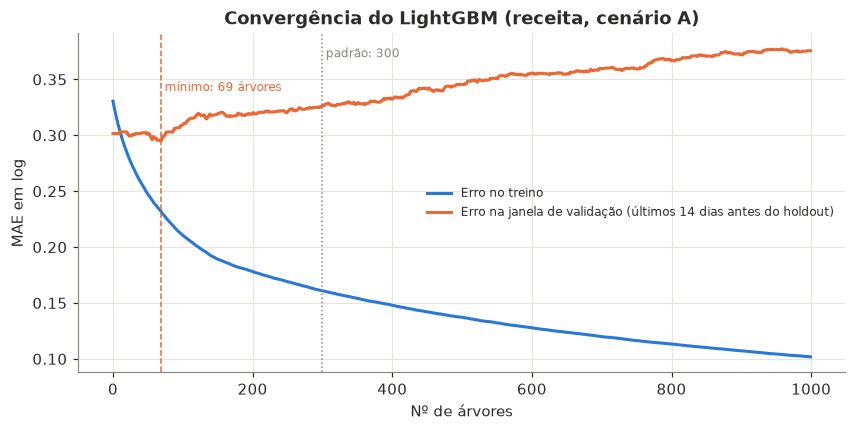

{'melhor_n_arvores_validacao': 69, 'erro_treino_final': 0.1018, 'erro_val_min': 0.295, 'erro_val_final': 0.3756}


In [9]:
alvo = 'receita_aprovada'
ph, fit, Xc, yy, n = saidas[(alvo, 'A. Sem plano promocional')]
melhor_lgbm = AJ[(alvo, 'LightGBM')][0]
tr, va = T.curva_convergencia(Xc, yy, n, melhor_lgbm)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(tr, color=AZUL, label='Erro no treino'); ax.plot(va, color=LARANJA, label='Erro na janela de validação (últimos 14 dias antes do holdout)')
ax.axvline(300, color=CINZA, ls=':', lw=1); ax.text(305, va.max() * .98, 'padrão: 300', fontsize=8, color=CINZA)
ax.axvline(int(va.argmin()), color=LARANJA, ls='--', lw=1); ax.text(int(va.argmin()) + 5, va.max() * .9, f'mínimo: {int(va.argmin())} árvores', fontsize=8, color=LARANJA)
ax.set_xlabel('Nº de árvores'); ax.set_ylabel('MAE em log'); ax.set_title('Convergência do LightGBM (receita, cenário A)'); ax.legend(fontsize=8)
salvar(fig, '13_convergencia'); plt.show()
R['convergencia'] = {'melhor_n_arvores_validacao': int(va.argmin()), 'erro_treino_final': round(float(tr[-1]), 4), 'erro_val_min': round(float(va.min()), 4), 'erro_val_final': round(float(va[-1]), 4)}
print(R['convergencia'])

**Leitura do ajuste.**
- **Ridge:** a penalidade maior (α = 300, contra 10) melhora de forma **consistente** em receita e pedidos, no walk-forward e no holdout. Com poucos dados e variáveis correlacionadas (lags e médias), encolher mais os coeficientes ajuda. É o único ajuste com ganho em todas as métricas.
- **LightGBM e XGBoost:** o ajuste **não generaliza**: a configuração vencedora nas 3 janelas internas melhora uma métrica e piora outra (ex.: LightGBM receita 27,5% → 28,5% no walk-forward e 30,4% → 27,3% no holdout). Com ~230 dias, a escolha entre configurações de árvores é dominada por ruído; árvores rasas (`max_depth = 1`) e muitas árvores são sinal de que o modelo está buscando quase um efeito aditivo simples.
- **Convergência:** o erro de treino cai sempre com mais árvores (0,10 em 1.000), mas o erro de validação atinge o mínimo em ~70 árvores e **sobe depois** (0,30 → 0,38). É o sinal clássico de sobreajuste: a partir daí o modelo decora o treino. A validação é de só 14 dias, então o ponto exato é incerto; a lição é usar poucas árvores, taxa baixa e regularização, como na configuração padrão.
- **Conclusão:** manter a configuração padrão para as árvores e adotar **Ridge com α = 300** como variante recomendada; as demais comparações do notebook usam as configurações iniciais.

## Teste de sensibilidade: o cenário B é circular?
A taxa de desconto do dia é calculada com a **venda realizada do próprio dia** (desconto ÷ venda bruta), então
o cenário B usa uma informação que, na prática, só se conhece depois. Para medir o quanto isso favorece o B,
comparo variantes da informação promocional, todas com o mesmo desenho de validação:
- **B1** taxa do dia (como no cenário B, é um limite superior otimista);
- **B2** taxa defasada em 7 dias e **B3** média de 7 dias defasada (não circulares, disponíveis na hora da previsão);
- **B4** taxa do dia com ruído multiplicativo (~20%), simulando um plano promocional impreciso.

In [10]:
def teste_sensibilidade():
    tx = d.tx_desc
    rng = np.random.default_rng(0)
    variantes = {
        'A. Sem informação de desconto': {},
        'B1. Taxa do dia (circular, otimista)': {'tx_dia': tx},
        'B2. Taxa defasada 7d': {'tx_l7': tx.shift(7)},
        'B3. Média 7d defasada': {'tx_m7': tx.shift(7).rolling(7).mean()},
        'B4. Taxa do dia com ruído de ~20%': {'tx_plano': tx * np.exp(rng.normal(0, 0.2, len(tx)))},
    }
    linhas = []
    for alvo in ALVOS:
        y = d[alvo]
        for vn, extra in variantes.items():
            X = calendario(y.index).join(com_defasagens(y))
            for k, v in extra.items(): X[k] = v
            X = X.dropna(); yy = y.loc[X.index]; n = len(yy) - DIAS_HOLDOUT
            def prever(a, b, c):
                return np.mean([prever_modelo(m, X.iloc[:a], yy.iloc[:a], X.iloc[b:c])[0] for m in modelos().values()], axis=0)
            wf = []
            for i in range(N_FOLDS):
                ini = n - PASSO * (N_FOLDS - i)
                wf.append(metricas(yy.iloc[ini:ini + PASSO], prever(ini, ini, ini + PASSO))['WAPE %'])
            ho = metricas(yy.iloc[n:], prever(n, n, len(yy)))['WAPE %']
            linhas.append({'alvo': alvo, 'informação promocional': vn, 'WAPE walk-forward (%)': np.mean(wf), 'WAPE holdout (%)': ho})
    return pd.DataFrame(linhas)

sens = teste_sensibilidade()
sens_tab = sens.pivot(index='informação promocional', columns='alvo', values=['WAPE walk-forward (%)', 'WAPE holdout (%)']).round(1)
sens_tab

WAPE walk-forward (%)                   \
alvo                                            nr_pedidos receita_aprovada   
informação promocional                                                        
A. Sem informação de desconto                         27.0             24.1   
B1. Taxa do dia (circular, otimista)                  24.5             25.1   
B2. Taxa defasada 7d                                  27.4             25.2   
B3. Média 7d defasada                                 27.6             24.2   
B4. Taxa do dia com ruído de ~20%                     26.9             24.4   

                                     WAPE holdout (%)                   
alvo                                       nr_pedidos receita_aprovada  
informação promocional                                                  
A. Sem informação de desconto                    27.4             29.9  
B1. Taxa do dia (circular, otimista)             24.0             29.3  
B2. Taxa defasada 7d                             27.2             29.6  
B3. Média 7d defasada                            24.1             26.8  
B4. Taxa do dia com ruído de ~20%                22.0             26.4

**Leitura honesta.** (média Ridge + LightGBM em todas as linhas)
- Com informação **não circular** (B2, B3) o erro **não melhora** frente ao cenário A: o histórico recente de desconto não prevê o dia seguinte.
- O ganho do B1 (principalmente em pedidos) vem de usar a taxa do próprio dia; é um **teto**, não uma expectativa realista.
- Com um plano com ruído (B4) o ganho se reduz e é pequeno em receita; só voltaria a ser relevante se o comercial fornecesse o plano com boa precisão.
- No holdout (apenas 30 dias) algumas variantes parecem ajudar a receita, mas o walk-forward, com mais janelas, não confirma; trato como ruído.
- **Conclusão:** o cenário A é o número a reportar como desempenho esperado; o B mostra o valor potencial de ter o calendário promocional bem estruturado.

In [11]:
R['sensibilidade'] = {f'{a}|{v}': {'wf': round(float(w), 1), 'ho': round(float(h), 1)}
                      for a, v, w, h in sens[['alvo', 'informação promocional', 'WAPE walk-forward (%)', 'WAPE holdout (%)']].itertuples(index=False)}

## Sensibilidade ao tratamento das linhas com receita ≤ 0
Três tratamentos para as ~4,9% de linhas com receita ≤ 0 (ver notebook 01):
- **Manter** como veio (receita líquida);
- **Descartar** as linhas (remove também os pedidos e itens delas);
- **|receita|** (hipótese de inversão de sinal; preserva pedidos e itens).

Mesmo modelo (média Ridge + LightGBM), cenário A, mesma validação, para os dois alvos.

In [12]:
_df = carregar()
COLS = ['receita_aprovada', 'nr_pedidos']
def serie(df_, abs_=False):
    x = df_.assign(receita_aprovada=df_.receita_aprovada.abs()) if abs_ else df_
    return x.groupby('data')[COLS].sum().asfreq('D')
series = {'Manter (líquida)': serie(_df), 'Descartar linhas ≤ 0': serie(_df[_df.receita_aprovada > 0]), 'Somar |receita|': serie(_df, abs_=True)}

def wape_cenario_a(y):
    X = calendario(y.index).join(com_defasagens(y)).dropna(); yy = y.loc[X.index]; n = len(yy) - DIAS_HOLDOUT
    def prever(a, b, c):
        return np.mean([prever_modelo(m_, X.iloc[:a], yy.iloc[:a], X.iloc[b:c])[0] for m_ in modelos().values()], axis=0)
    wf = [metricas(yy.iloc[i:i + PASSO], prever(i, i, i + PASSO))['WAPE %'] for i in [n - PASSO * (N_FOLDS - k) for k in range(N_FOLDS)]]
    return np.mean(wf), metricas(yy.iloc[n:], prever(n, n, len(yy)))['WAPE %']

linhas = []
for alvo, rotulo in ALVOS.items():
    for nome, s in series.items():
        wf, ho = wape_cenario_a(s[alvo])
        linhas.append({'alvo': rotulo, 'tratamento': nome, 'WAPE walk-forward (%)': wf, 'WAPE holdout (%)': ho,
                       'nível médio diário vs. manter (%)': 100 * (s[alvo].mean() / series['Manter (líquida)'][alvo].mean() - 1)})
sens_trat = pd.DataFrame(linhas).set_index(['alvo', 'tratamento']).round(1)
R['sens_tratamento_neg'] = {f'{a}|{t_}': v for (a, t_), v in sens_trat.to_dict('index').items()}
sens_trat

WAPE walk-forward (%)  \
alvo             tratamento                                    
Receita aprovada Manter (líquida)                       24.1   
                 Descartar linhas ≤ 0                   23.3   
                 Somar |receita|                        23.1   
Nº de pedidos    Manter (líquida)                       27.0   
                 Descartar linhas ≤ 0                   27.2   
                 Somar |receita|                        27.0   

                                       WAPE holdout (%)  \
alvo             tratamento                               
Receita aprovada Manter (líquida)                  29.9   
                 Descartar linhas ≤ 0              29.2   
                 Somar |receita|                   29.2   
Nº de pedidos    Manter (líquida)                  27.4   
                 Descartar linhas ≤ 0              27.5   
                 Somar |receita|                   27.4   

                                       nível médio diário vs. manter (%)  
alvo             tratamento                                               
Receita aprovada Manter (líquida)                                    0.0  
                 Descartar linhas ≤ 0                                4.3  
                 Somar |receita|                                     8.6  
Nº de pedidos    Manter (líquida)                                    0.0  
                 Descartar linhas ≤ 0                               -4.1  
                 Somar |receita|                                     0.0

**Leitura.**
- **Erro relativo (WAPE):** praticamente igual nos três tratamentos (diferenças de até ~0,6 p.p. entre eles), dentro do ruído de um teste de 86 dias.
  Os WAPE são calculados contra séries diferentes, então a comparação é aproximada.
- **Nível:** muda. Descartar eleva a receita diária em ~4% e reduz os pedidos em ~4%; |receita| eleva a receita em ~9% sem alterar pedidos.
  O modelo prevê "o número que o tratamento define": se a receita oficial for a líquida, descartar faz o modelo prever ~4% acima do reportado.
- **Escopo:** testado só no cenário A, na série diária total. Em granularidade fina (hora × categoria × canal) o efeito seria maior.
- **Coerência:** se as linhas forem erro de sinal, descartar também perde pedidos/itens válidos; |receita| é o tratamento mais coerente com essa hipótese.
- **Decisão:** manter como veio até o dono do dado confirmar a natureza dessas linhas.

## Teste: o modelo precisa da variável `t` (tendência)?
`t` é um contador de dias (0 em 01/11/2025). Fora de novembro, a série não tem tendência (inclinação de ≈ −0,02% ao dia; a correlação de `t` com a receita é −0,38 no período todo e −0,04 sem novembro):
a "queda" que `t` capturava era o fim da campanha, hoje representada por `beauty_week`. Refaço a validação (cenário A) com e sem `t`.

In [13]:
from src.features import montar as _montar
def comparar_sem_t():
    linhas = []
    for alvo, rotulo in ALVOS.items():
        y = d[alvo]; X0 = _montar(y).dropna(); yy = y.loc[X0.index]; n = len(yy) - DIAS_HOLDOUT
        jan = T.janelas_externas(n)
        for variante, X in [('com t', X0), ('sem t', X0.drop(columns='t'))]:
            pf = {nm: [prever_modelo(mk, X.iloc[:a], yy.iloc[:a], X.iloc[a:b])[0] for a, b in jan] for nm, mk in modelos().items()}
            ph = {nm: prever_modelo(mk, X.iloc[:n], yy.iloc[:n], X.iloc[n:])[0] for nm, mk in modelos().items()}
            for nm in ['Ridge', 'LightGBM', 'Média Ridge+LGBM']:
                if nm.startswith('Média'):
                    f = [(pf['Ridge'][i] + pf['LightGBM'][i]) / 2 for i in range(len(jan))]; h = (ph['Ridge'] + ph['LightGBM']) / 2
                else:
                    f, h = pf[nm], ph[nm]
                wf = np.mean([metricas(yy.iloc[a:b], f[i])['WAPE %'] for i, (a, b) in enumerate(jan)])
                linhas.append({'alvo': rotulo, 'modelo': nm, 'variante': variante, 'WAPE walk-forward (%)': wf, 'WAPE holdout (%)': metricas(yy.iloc[n:], h)['WAPE %']})
    return pd.DataFrame(linhas)
t_df = comparar_sem_t()
t_tab = t_df.pivot_table(index=['alvo', 'modelo'], columns='variante', values=['WAPE walk-forward (%)', 'WAPE holdout (%)']).round(1)
R['teste_sem_t'] = {f'{a}|{m_}|{v}': {'wf': round(float(w), 1), 'ho': round(float(h), 1)} for a, m_, v, w, h in t_df[['alvo', 'modelo', 'variante', 'WAPE walk-forward (%)', 'WAPE holdout (%)']].itertuples(index=False)}
t_tab

WAPE holdout (%)        \
variante                                     com t sem t   
alvo             modelo                                    
Nº de pedidos    LightGBM                     28.9  25.6   
                 Média Ridge+LGBM             27.4  25.2   
                 Ridge                        27.3  26.9   
Receita aprovada LightGBM                     30.4  31.4   
                 Média Ridge+LGBM             29.9  28.9   
                 Ridge                        29.6  27.4   

                                  WAPE walk-forward (%)        
variante                                          com t sem t  
alvo             modelo                                        
Nº de pedidos    LightGBM                          27.9  27.3  
                 Média Ridge+LGBM                  27.0  26.1  
                 Ridge                             27.2  25.8  
Receita aprovada LightGBM                          27.5  29.5  
                 Média Ridge+LGBM                  24.1  24.6  
                 Ridge                             23.6  21.9

**Leitura.**
- **Ridge:** melhora nas quatro métricas sem `t` (receita: 23,6% → 21,9% no walk-forward e 29,6% → 27,4% no holdout; pedidos: 27,2% → 25,8% e 27,3% → 26,9%). Uma reta no tempo não ajuda o modelo linear e ainda o deixa extrapolar uma tendência que não existe.
- **LightGBM:** resultado misto (piora na receita, 27,5% → 29,5% no walk-forward; melhora em pedidos). As árvores usam `t` como marcador de época, o que pode compensar mudanças de nível que não estão em outras variáveis.
- **Média:** praticamente neutra na receita no walk-forward (24,1% → 24,6%) e melhor em pedidos.
- As diferenças são de 1 a 2 pontos, no limite do ruído de um teste curto; o que chama atenção é a **consistência no Ridge**. A variável é candidata a sair do modelo, ao menos do linear.
- **Decisão:** mantive `t` no pipeline principal para não alterar de novo todos os resultados e comparações já apresentados; a remoção fica como melhoria recomendada (reexecutar notebooks 02 e 03 e o deck).

## Importância das variáveis
Duas leituras complementares, nos **dois cenários** (A: sem desconto; B: com a taxa do dia, circular):
- **Permutação fora da amostra (LightGBM):** em cada janela do walk-forward, o modelo é treinado no passado; depois embaralha-se uma
  variável por vez nos 56 dias de teste e mede-se quanto o erro (MAE em log) piora. Quanto maior a piora, mais o modelo depende dela
  *para prever dias que não viu*.
- **Coeficientes padronizados (Ridge):** efeito, no log da receita, de subir 1 desvio-padrão da variável.

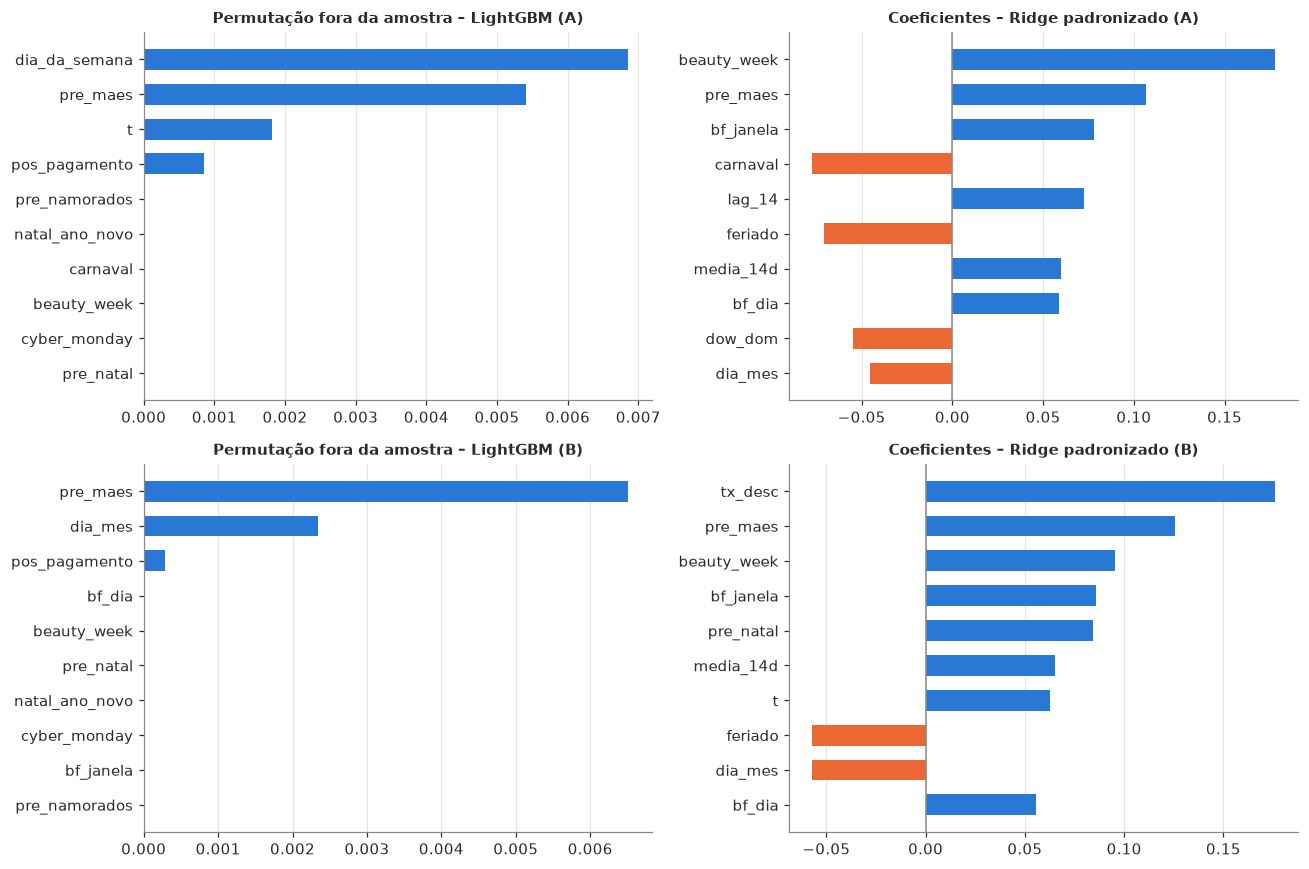

Cenário A – permutação: {'dia_da_semana': 0.0069, 'pre_maes': 0.0054, 't': 0.0018, 'pos_pagamento': 0.0008, 'pre_namorados': 0.0, 'natal_ano_novo': 0.0, 'carnaval': 0.0, 'beauty_week': 0.0}
Cenário A – coeficientes: {'beauty_week': 0.178, 'pre_maes': 0.107, 'bf_janela': 0.078, 'carnaval': -0.077, 'lag_14': 0.072, 'feriado': -0.071, 'media_14d': 0.06, 'bf_dia': 0.059}
Cenário B – permutação: {'pre_maes': 0.0065, 'dia_mes': 0.0023, 'pos_pagamento': 0.0003, 'bf_dia': 0.0, 'beauty_week': 0.0, 'pre_natal': 0.0, 'natal_ano_novo': 0.0, 'cyber_monday': 0.0}
Cenário B – coeficientes: {'tx_desc': 0.176, 'pre_maes': 0.126, 'beauty_week': 0.095, 'bf_janela': 0.086, 'pre_natal': 0.085, 'media_14d': 0.065, 't': 0.063, 'feriado': -0.057}


In [14]:
def importancia_permutacao(X, yy, n, n_rep=40, seed=0):
    rng = np.random.default_rng(seed)
    janelas = [(n - PASSO * (N_FOLDS - i), n - PASSO * (N_FOLDS - i - 1)) for i in range(N_FOLDS)]
    modelos_fold = [modelos()['LightGBM']().fit(X.iloc[:a], np.log1p(yy.iloc[:a])) for a, _ in janelas]
    a0, b0 = janelas[0][0], janelas[-1][1]
    Xte, yte = X.iloc[a0:b0], np.log1p(yy.iloc[a0:b0].values)
    def mae(Xp):
        p = np.concatenate([m.predict(Xp.iloc[a - a0:b - a0]) for m, (a, b) in zip(modelos_fold, janelas)])
        return np.mean(np.abs(p - yte))
    base = mae(Xte)
    grupos = {'dia_da_semana': [c for c in X.columns if c.startswith('dow_') or c == 'fim_semana']}
    unidades = {c: [c] for c in X.columns if c not in grupos['dia_da_semana']} | grupos  # dummies do dia da semana são embaralhadas juntas
    imp = {}
    for nome, cols in unidades.items():
        piora = []
        for _ in range(n_rep):
            Xp = Xte.copy(); Xp[cols] = Xte[cols].values[rng.permutation(len(Xte))]; piora.append(mae(Xp) - base)
        imp[nome] = np.mean(piora)
    return pd.Series(imp).sort_values(ascending=False), base

alvo = 'receita_aprovada'
IMP, COEF = {}, {}
for cen in ['A. Sem plano promocional', 'B. Com plano promocional (teto)']:
    ph, fit, Xc, yy, n = saidas[(alvo, cen)]
    IMP[cen], _ = importancia_permutacao(Xc, yy, n)
    c = pd.Series(fit['Ridge'][-1].coef_, index=Xc.columns); COEF[cen] = c.reindex(c.abs().sort_values(ascending=False).index)
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
for r, cen in enumerate(IMP):
    top = IMP[cen].head(10).iloc[::-1]
    axs[r, 0].barh(top.index, top.values, color=AZUL, height=.6); axs[r, 0].set_title(f'Permutação fora da amostra – LightGBM ({cen[0]})', fontsize=10); axs[r, 0].grid(axis='y', visible=False)
    cc = COEF[cen].head(10).iloc[::-1]
    axs[r, 1].barh(cc.index, cc.values, color=[AZUL if v >= 0 else LARANJA for v in cc.values], height=.6); axs[r, 1].axvline(0, color=CINZA, lw=1)
    axs[r, 1].set_title(f'Coeficientes – Ridge padronizado ({cen[0]})', fontsize=10); axs[r, 1].grid(axis='y', visible=False)
plt.tight_layout(); salvar(fig, '09_importancia'); plt.show()
R['importancia_perm'] = {c[0]: IMP[c].head(8).round(4).to_dict() for c in IMP}
R['importancia_coef'] = {c[0]: COEF[c].head(8).round(3).to_dict() for c in COEF}
R['importancia_perm_todas_A'] = IMP['A. Sem plano promocional'].round(4).to_dict()
R['coef_todas_A'] = COEF['A. Sem plano promocional'].round(3).to_dict()
print('Cenário A – permutação:', R['importancia_perm']['A']); print('Cenário A – coeficientes:', R['importancia_coef']['A'])
print('Cenário B – permutação:', R['importancia_perm']['B']); print('Cenário B – coeficientes:', R['importancia_coef']['B'])

**Cuidados na leitura.**
- O cenário A é a referência honesta; no B a liderança de `tx_desc` vem de uma variável circular (usa a venda do dia).
- Variáveis de evento (`bf_janela`, `pre_natal`, `pre_maes`...) têm coeficientes altos no Ridge, mas cada uma vem de **uma única ocorrência**: indicam que o modelo acomodou aqueles picos, não que o efeito esteja medido com precisão. Como os eventos só aparecem em parte das janelas de teste, a permutação fora da amostra os valoriza pouco.
- Variáveis correlacionadas (lags e médias móveis) dividem importância entre si.
- **`beauty_week` não aparece na permutação** porque todas as janelas de teste ficam fora de novembro (a variável é constante nelas). Seu efeito só é visível no coeficiente do Ridge (≈ +19% no nível diário em novembro, com as demais variáveis controladas), e vem de um único novembro.
- **A importância fora da amostra é instável:** são só 56 dias de teste. Por exemplo, a de `tx_desc` no cenário B foi ~0,0002 quando o dia da semana entrava como número e ~0,0065 depois de transformá-lo em variáveis binárias. Use o ranking como indício (histórico do mesmo dia da semana, dia da semana, Dia das Mães, tendência), não como medida precisa.

## Análise de resíduos e limites do modelo

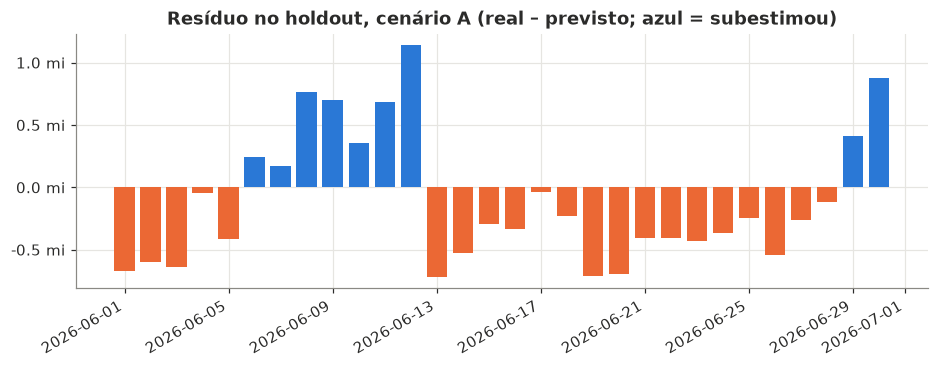

Maiores erros absolutos:


data
2026-06-12    1138877.0
2026-06-30     876539.0
2026-06-08     761045.0
2026-06-13     715006.0
2026-06-19     710064.0
Name: receita_aprovada, dtype: float64

In [15]:
ph, fit, Xc, yy, n = saidas[('receita_aprovada', 'A. Sem plano promocional')]
res = (yy.iloc[n:] - ph[final[('receita_aprovada', 'A. Sem plano promocional')]])
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.bar(res.index, res.values, color=[AZUL if v >= 0 else LARANJA for v in res.values], width=.8)
ax.yaxis.set_major_formatter(FuncFormatter(milhoes)); ax.set_title('Resíduo no holdout, cenário A (real – previsto; azul = subestimou)')
fig.autofmt_xdate(); salvar(fig, '10_residuos'); plt.show()
print('Maiores erros absolutos:'); display(res.abs().sort_values(ascending=False).head(5).round(0))

**Limites que valem explicitar:**
1. **Um único Natal, uma única Black Friday, nenhum ciclo anual:** efeitos sazonais anuais são estimados com 1 observação; não validei o comportamento deles fora da amostra.
2. **Picos promocionais e eventos não calendarizados** geram os maiores resíduos (12/06, 30/06, 8–9/06 e 01/06 no holdout); a queda de 13–14/06 também fica sem explicação. Sem um calendário de mídia/campanhas e de eventos externos, esse erro é difícil de reduzir.
3. **O cenário B é um teto otimista:** usa a taxa de desconto do próprio dia, calculada com a venda realizada. O teste de sensibilidade mostra que, sem essa circularidade, não há ganho sobre o cenário A.
4. WAPE na faixa de 20–30% é adequado para planejamento semanal agregado, não para metas diárias rígidas.

In [16]:
for k, v in final.items(): print(k, '->', v)
R['resumo'] = {f'{a}|{c}': {'modelo': final[(a, c)], **{kk: round(float(vv), 1) for kk, vv in resumo.loc[[(a, c)]].iloc[0].items() if kk != 'modelo escolhido'}} for (a, c) in final}
R['tabelas'] = {f'{a}|{c}': t.round(1).to_dict('index') for (a, c), t in tabelas.items()}
json.dump(R, open('../reports/resultados_modelo.json', 'w'), ensure_ascii=False, indent=2, default=float)

('receita_aprovada', 'A. Sem plano promocional') -> Ridge
('receita_aprovada', 'B. Com plano promocional (teto)') -> Ridge
('nr_pedidos', 'A. Sem plano promocional') -> Média Ridge+LGBM
('nr_pedidos', 'B. Com plano promocional (teto)') -> Ridge
